### Fisher’s Linear Discriminant - Fişerin xətti diskriminantı 

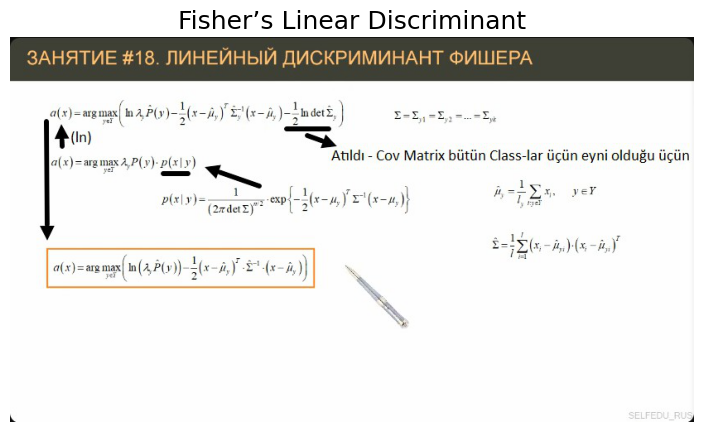

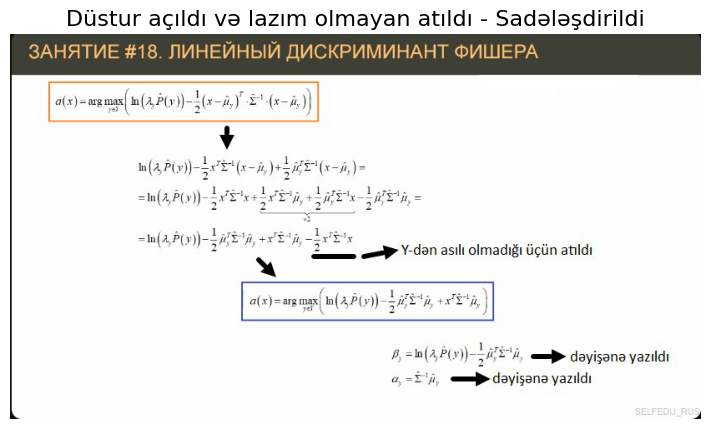

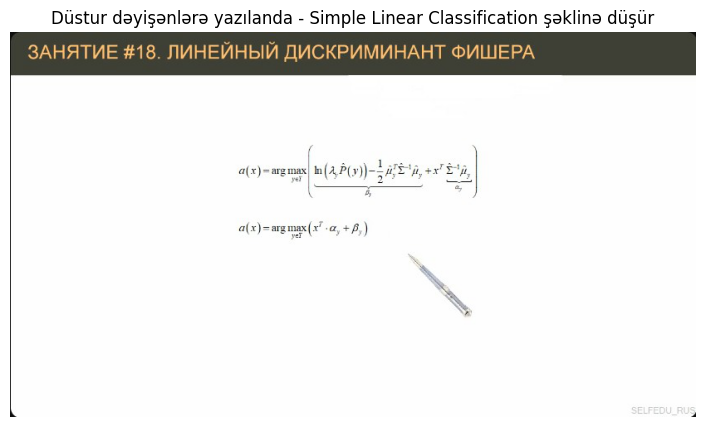

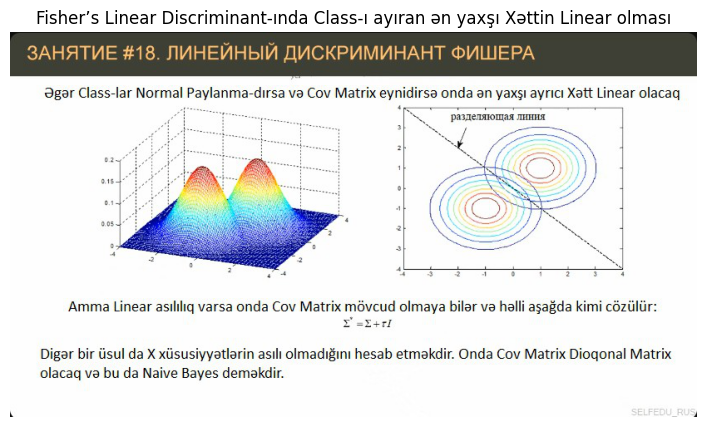

In [6]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_18_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 5):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))      
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Fisher’s Linear Discriminant""", size='18')
    elif i < 2:
        plt.title("""Düstur açıldı və lazım olmayan atıldı - Sadələşdirildi""", size='16')
    elif i < 3:
        plt.title("""Düstur dəyişənlərə yazılanda - Simple Linear Classification şəklinə düşür""", size='12')
    elif i < 4:
        plt.title("""Fisher’s Linear Discriminant-ında Class-ı ayıran ən yaxşı Xəttin Linear olması""", size='12')        
        
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### Əsas prinsip



> **Ayrıcı Xətt Linear olur, çünki əvvəlcə hər klass üçün $ \hat{\Sigma}_j $ (Class kovariasiya matrisləri) eyni ümumi $ \hat{\Sigma} $ ilə əvəz edilir və  $\frac{1}{2} \ln \det \hat{\Sigma}_j$ atılır, bundan sonra $x^T \Sigma^{-1} x$ tipli kvadratik terminlər Classdan ($y$-dən) asılı olmadığı üçün hər iki tərəfdə eyni formada olub bir-birini ixtisar edir (yəni atılır) və nəticədə qərar sərhədi düsturu dəyişənlərlə əvəz edildikə görsənirki yalnız $a(x)= x^T \alpha_y + \beta_y$ formasında Linear (Xətti) ifadə kimi qalır.**



### Gaussian Bayes Classifier əsas düsturları:
#### 1️⃣ Gaussian ehtimal sıxlığı funksiyası (likelihood)
#### 2️⃣ Posterior ehtimalı maximallaşdırmaq üçün (Bayes qərarı)
#### 3️⃣ Log-space formulu $α(x)$ - Model Classification
#### 4️⃣ Fisher’s Linear Discriminant üçün sadələşdirilmiş MAP qərarı - Model Classification



#### 1️⃣ Gaussian ehtimal sıxlığı funksiyası (likelihood)

$$
p(x \mid y) = \frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}} \exp\Big(-\frac{1}{2} (x - \mu_y)^T \Sigma_y^{-1} (x - \mu_y)\Big)
$$

**İzahı:**

* Bu düstur $x$ vektorunun $y$ sinifinə aid olma ehtimalını göstərir (likelihood).
* Burada:

  * $\mu_y$ → sinif $y$-nin orta vektoru
  * $\Sigma_y$ → sinif $y$-nin kovariasiya matrisi
  * $n$ → xüsusiyyətlərin sayı
* Bu düstur **multivariate normal distribution**-dan alınır.

---

#### 2️⃣ Posterior ehtimalı maximallaşdırmaq üçün (Bayes qərarı)

$$
a(x) = \arg\max_{y \in Y} P(y) \cdot p(x \mid y)
$$

**İzahı:**

* $a(x)$ → Bayes Classifier tərəfindən verilən **proqnozlaşdırılan sinif**
* Bayes teoreminə əsaslanır: $P(y \mid x) \propto P(y) \cdot p(x \mid y)$
* Burada:

  * $P(y)$ → sinifin prior ehtimalı
  * $p(x \mid y)$ → likelihood (yuxarıdakı Gaussian formula)
* Bu düstur **maksimum a posteriori (MAP) qərar qaydasıdır**.

---

#### 3️⃣ Log-space formulu $α(x)$

$$
Model Classification
$$

$$
\alpha(x) = \arg\max_{y \in T} \Big( \ln \hat{P}(y) - \frac{1}{2} (x - \hat{\mu}_j)^T \hat{\Sigma}_j^{-1} (x - \hat{\mu}_j) - \frac{1}{2} \ln \det \hat{\Sigma}_j \Big)
$$

**İzahı:**

* Bu, **log-transform edilmiş** versiondur.
* Multiplikasiya əvəzinə toplama ilə işləyir (rəqəmlərlə daha stabil olur).
* Burada:

  * $\hat{P}(y)$, $\hat{\mu}_j$, $\hat{\Sigma}_j$ → təlim datasından **təxmin edilən** prior, orta və kovariasiya
  * $\ln \det \hat{\Sigma}_j$ → normalizasiya faktoru log-düzənlənmiş formada
* Bu düstur **praktikada Gaussian Bayes Classifier-in implementasiyasında** istifadə olunur.

---

#### 4️⃣ Fisher’s Linear Discriminant üçün sadələşdirilmiş MAP qərarı

$$
Model Classification
$$

$$
\alpha(x) = \arg\max_{y \in T} \Big( \ln \hat{P}(y) - \frac{1}{2} (x - \hat{\mu}_j)^T \hat{\Sigma}_j^{-1} (x - \hat{\mu}_j) \Big)
$$

**İzahı:**

* Bu düstur **log-space formulanın sadələşdirilmiş versiyasıdır**.
* **Atılan term:**
  $$
 \frac{1}{2} \ln \det \hat{\Sigma}_j
  $$
    → log-determinant normalizasiya faktoru
* **Niyə atılıb:**

  * **Əgər bütün siniflər üçün kovariasiya matrisi $\Sigma_j$ eynidirsə, $\det \Sigma_j$ sabitdir və argmax əməliyyatına heç bir təsiri yoxdur.**
  * Bu, implementasiyanı sadələşdirir, hesablamaları azaldır.
* **Adı və tətbiqi:**

  * Bu formül **Fisher’s Linear Discriminant (FLD)** üçün əsas MAP qərarı kimi istifadə olunur.
  * Əsas ideya: posterior ehtimalı maximallaşdırmaq üçün hər sinif üçün Mahalanobis məsafəni və prior ehtimalı nəzərə alaraq qərar qəbul edilir.




✅ **Xülasə:**

| Düstur                                                                                                                                              | Mənbə / Haradan alınıb                          |
| --------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------- |
| $$p(x \mid y) = \frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}} \exp(-\frac12 (x-\mu_y)^T \Sigma_y^{-1} (x-\mu_y))$$                                      | Multivariate Gaussian likelihood                |
| $$a(x) = \arg\max_{y \in Y} P(y) \cdot p(x \mid y)$$                                                                                                  | Bayes qərar qaydası (posterior maximallaşdırma) |
| $$\alpha(x) = \arg\max_{y \in T} (\ln \hat{P}(y) - \frac12 (x-\hat{\mu}_j)^T \hat{\Sigma}_j^{-1} (x-\hat{\mu}_j) - \frac12 \ln \det \hat{\Sigma}_j)$$ | Log-space praktik implementasiya (MAP qərarı)   |
| $$\alpha(x) = \arg\max_{y \in T} (\ln \hat{P}(y) - \frac12 (x-\hat{\mu}_j)^T \hat{\Sigma}_j^{-1} (x-\hat{\mu}_j))$$                                   | Fisher’s Linear Discriminant üçün sadələşdirilmiş MAP qərarı ($\frac{1}{2} \ln \det \hat{\Sigma}_j $ atılıb)        |



#### Fisher’s Linear Discriminantın özünü sadələşdirilib Linear formya salınması



#### 1️⃣ Əsas qərar funksiyası

$$
a(x) = \arg \max_{y \in Y} \left( \ln(\lambda_y \hat{P}(y)) - \frac{1}{2}(x - \hat{\mu}_y)^T \cdot \hat{\Sigma}^{-1} \cdot (x - \hat{\mu}_y) \right)
$$

---

#### 2️⃣ Kvadratik hissənin açılmış forması

$$
= \ln(\lambda_y \hat{P}(y)) - \frac{1}{2}x^T \hat{\Sigma}^{-1} x + \underbrace{\frac{1}{2}x^T \hat{\Sigma}^{-1} \hat{\mu}_y + \frac{1}{2} \hat{\mu}_y^T \hat{\Sigma}^{-1} x}_{\times 2} - \frac{1}{2} \hat{\mu}_y^T \hat{\Sigma}^{-1} \hat{\mu}_y 
$$

---

#### 3️⃣ Sadələşdirilmiş forma

$$
= \ln(\lambda_y \hat{P}(y)) - \frac{1}{2} \hat{\mu}_y^T \hat{\Sigma}^{-1} \hat{\mu}_y + x^T \hat{\Sigma}^{-1} \hat{\mu}_y - \frac{1}{2} x^T \hat{\Sigma}^{-1} x
$$


---

#### 4️⃣ Hansı hissə ixtisar olur?

Diqqət et:

$$
-\frac12 x^T\hat\Sigma^{-1}x
$$

> Bu **Kvadratik** termin **y-dən asılı deyil**.

Biz isə

$$
a(x)=\arg\max_y g_y(x)
$$

hesablayırıq.

**Argmax zamanı y-dən asılı olmayan sabitlər qərara təsir etmir ❗**

Ona görə bu hissəni ata bilərik.

$$
$$

#### Qalan ifadə

$$
a(x)=
x^T\hat\Sigma^{-1}\hat\mu_y
-\frac12 \hat\mu_y^T\hat\Sigma^{-1}\hat\mu_y
+\ln(\lambda_y \hat P(y))
$$

$$
$$

#### Linear forma yazılışı

İndi bunu belə yaza bilərik:

$$
a(x)= x^T \alpha_y + \beta_y
$$

burada

$$
\alpha_y = \hat\Sigma^{-1}\hat\mu_y
$$

$$
\beta_y = -\frac{1}{2} \hat{\mu}_y^T \hat{\Sigma}^{-1} \hat{\mu}_y
+ \ln(\lambda_y \hat{P}(y))
$$

$$
$$

#### Nəticə

Qərar qaydası:

$$
a(x)=\arg\max_y (x^T \alpha_y + \beta_y)
$$

> Bu artıq **tam linear classifier** formasındadır.

$$
$$

#### 🔎 Niyə linear oldu?

Çünki:

* Bütün klasslar üçün covariance eyni qəbul edildi
  $$
  \Sigma_y = \Sigma
  $$
* Ona görə də kvadratik termin
  $$
  x^T\Sigma^{-1}x
  $$
  hamı üçün eyni oldu və ixtisar edildi.

Əgər:

$$
\Sigma_y \neq \Sigma
$$

olsaydı, onda o termin qalacaqdı və qərar səthi **kvadratik (QDA)** olacaqdı.

